 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL:** 

**EXAMEN 2.**
===
EZAU FARIDH TORRES TORRES.
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 23/05/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                                  # library for numerical operations.
import matplotlib.pyplot as plt                     # library for plotting.
import torch                                        # library for tensor operations.
from nltk.tokenize import TweetTokenizer            # library for tweet tokenization.
from nltk.corpus import stopwords                   # library for stopwords.
stopwords_es = set(stopwords.words('spanish'))      # set of spanish stopwords.
import os                                           # library for operating system.
import time                                         # library for time.
from typing import (Tuple, Callable, List,          # library for typing.
                    Optional, Union, Dict)          # library for typing.
import random                                       # library for random numbers.
import pandas as pd                                 # library for data manipulation.
from collections import defaultdict, Counter        # library for collections.
from tqdm import tqdm                               # library for progress bar.
import torch.nn as nn                               # library for neural network operations.
import torch.nn.functional as F                     # library for functional operations.
from torch.utils.data import (DataLoader,           # library for data loading.
                              Dataset)              # library for dataset.
from sklearn.metrics import (confusion_matrix,      # library for evaluation.
                             classification_report) # library for evaluation.                   
import csv                                          # library for csv operations.
from torch import optim                             # for neural networks.
from colorama import Fore, Style                    # library for colored text.
import seaborn as sns                               # library for data visualization.
sns.set_style("darkgrid")                           # set style for seaborn.
import xml.etree.ElementTree as ET                  # library for xml parsing.
np.random.seed(0)                                   # seed for reproducibility.
random.seed(0)                                      # seed for reproducibility.
torch.manual_seed(0)                                # seed for reproducibility.
torch.backends.cudnn.benchmark = False              # reproducibility.

In [2]:
def load_data_by_user(folder_path: str, return_labels: bool = True
                      ) -> Union[Dict[str, List[str]], Tuple[Dict[str, List[str]], Dict[str, Tuple[str, str]]]]:
    """
    Load data and labels from the specified folder. This generates a dictionary mapping user IDs to lists of
    tweets. If return_labels is True, it also returns a dictionary mapping user IDs to tuples of labels.

    Parameters
    ----------
    folder_path : str
        Path to the folder containing XML files and a truth file.
    return_labels : bool, optional
        If True, return labels from the truth file. Default is True.
    
    Returns
    -------
    user_to_tweets : dict
        Dictionary mapping user IDs to lists of tweets.
    user_to_labels : dict, optional
        Dictionary mapping user IDs to tuples of labels. 
    """
    # Load labels from truth.txt of truth_order.txt.
    truth_file = 'truth.txt' if os.path.exists(os.path.join(folder_path, 'truth.txt')) else 'truth_order.txt'
    truth_path = os.path.join(folder_path, truth_file)

    if return_labels and not os.path.exists(truth_path):
        raise FileNotFoundError(f"Truth file not found in {folder_path}.")

    user_to_labels = {} # Dictionary to store the labels: user_id -> labels.
    if return_labels:
        with open(truth_path, 'r', encoding = 'utf-8') as f:         # Open the file.
            for line in f:                                           # Read the file line by line.
                user_id, gender, country = line.strip().split(':::') # Unpack the parts.
                user_to_labels[user_id] = (gender, country)          # Store the labels in the dictionary.

    # Load tweets from XML files.
    user_to_tweets = defaultdict(list)       # Dictionary to store the tweets: user_id -> list of tweets.
    for filename in os.listdir(folder_path): # Iterate over the files in the folder.
        if not filename.endswith('.xml'):    # Iterate over the XML files in the folder.
            continue
        user_id = filename.replace('.xml', '')          # Extract user ID from filename.
        file_path = os.path.join(folder_path, filename) # Construct the full file path.

        # Parse the XML file and extract the text.
        tree = ET.parse(file_path)
        root = tree.getroot()
        documents = root.find('documents')

        # Check if the documents element exists.
        if documents is None:
            continue
        for doc in documents.findall('document'):
            if doc.text:
                user_to_tweets[user_id].append(doc.text.strip())

    return (user_to_tweets, user_to_labels) if return_labels else user_to_tweets

def explore_users(user_to_tweets: Dict[str, List[str]], name: str) -> None:
    """
    Explore the data and print statistics.
    """
    tweet_counts = [len(tweets) for tweets in user_to_tweets.values()]
    print(f'➤ Stats for {name}')
    print(f'    Users count     : {len(user_to_tweets)}')
    print(f'    Total tweets    : {sum(tweet_counts)}')
    print(f'    Avg tweets/user : {np.mean(tweet_counts):.2f}')
    print(f'    Min tweets/user : {min(tweet_counts)}')
    print(f'    Max tweets/user : {max(tweet_counts)}\n')

In [3]:
# Load data and labels for training, validation and testing.
user_to_tweets_train, user_to_labels_train = load_data_by_user(folder_path = 'data/es_train')
user_to_tweets_val, user_to_labels_val = load_data_by_user(folder_path = 'data/es_val')
user_to_tweets_test = load_data_by_user(folder_path = 'data/es_test', return_labels = False)

genders = set(label[0] for label in user_to_labels_train.values())
countries = set(label[1] for label in user_to_labels_train.values())
print(f'Number of genres    : {len(genders)}')
print(f'Number of countries : {len(countries)}')
print("")
print('Example of tweet')
user = 'f54e1a95965ea984606de6eec5d7cf32'
tweets = user_to_tweets_train[user]        
label = user_to_labels_train[user]               
print(f'Tweet   : {tweets[0]}')
print(f'User    : {user}')
print(f'Gender  : {label[0]}')           
print(f'Country : {label[1]}')         
print("")

# Explore the data for training and validation sets.
explore_users(user_to_tweets_train, 'Training')
explore_users(user_to_tweets_val, 'Validation')
explore_users(user_to_tweets_test, 'Test')

Number of genres    : 2
Number of countries : 7

Example of tweet
Tweet   : Se soltó el moño el loco Trump!!! Pareciera que aquí en Venezuela está prohibido ni mencionarlo... Medio extraño no????? El imperio Mesmo.
User    : f54e1a95965ea984606de6eec5d7cf32
Gender  : male
Country : venezuela

➤ Stats for Training
    Users count     : 3360
    Total tweets    : 335998
    Avg tweets/user : 100.00
    Min tweets/user : 99
    Max tweets/user : 100

➤ Stats for Validation
    Users count     : 840
    Total tweets    : 84000
    Avg tweets/user : 100.00
    Min tweets/user : 100
    Max tweets/user : 100

➤ Stats for Test
    Users count     : 2800
    Total tweets    : 280000
    Avg tweets/user : 100.00
    Min tweets/user : 100
    Max tweets/user : 100



In [4]:
def plot_distribution(user_to_tweets_train: dict, user_to_tweets_val: dict,
                      user_to_labels_train: dict, user_to_labels_val: dict, plot_type: str) -> None:

    def annotate_bars(ax):
        for p in ax.patches:
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + 1, int(height),
                        ha = "center", va = "bottom", fontsize = 9, weight = 'bold')

    fig, axs = plt.subplots(2, 2, figsize = (12,8), sharey = 'row')

    if plot_type == 'tweets':
        def expand_labels(user_to_tweets: dict, label_dict: dict) -> pd.DataFrame:
            data = []
            for user_id, tweets in user_to_tweets.items():
                if user_id in label_dict:
                    gender, country = label_dict[user_id]
                    for _ in tweets:
                        data.append((gender, country))
            return pd.DataFrame(data, columns = ["gender", "country"])

        df_train = expand_labels(user_to_tweets_train, user_to_labels_train)
        df_val   = expand_labels(user_to_tweets_val, user_to_labels_val)

        gender_order  = ['female', 'male']
        country_order = sorted(set(df_train['country']) | set(df_val['country']))

        fig.suptitle('Distribution of tweets of training and validation data', fontsize = 16, weight = 'bold')

        sns.countplot(data = df_train, x = "gender", hue = "gender", ax = axs[0,0], order = gender_order, hue_order = gender_order, palette = "YlGnBu_d")
        sns.countplot(data = df_train, x = "country", hue = "country", ax = axs[0,1], order = country_order, hue_order = country_order, palette = "Oranges_d")
        sns.countplot(data = df_val,   x = "gender", hue = "gender", ax = axs[1,0], order = gender_order, hue_order = gender_order, palette = "YlGnBu_d")
        sns.countplot(data = df_val,   x = "country", hue = "country", ax = axs[1,1], order = country_order, hue_order = country_order, palette = "Oranges_d")

        axs[0,0].set_ylabel("Tweets", fontsize = 12, weight = 'bold')
        axs[1,0].set_ylabel("Tweets", fontsize = 12, weight = 'bold')
        axs[0,1].set_ylabel("")
        axs[1,1].set_ylabel("")

    elif plot_type == 'users':
        df_train = pd.DataFrame(list(user_to_labels_train.values()), columns = ["gender", "country"])
        df_val   = pd.DataFrame(list(user_to_labels_val.values()),   columns = ["gender", "country"])

        gender_order  = ['female', 'male']
        country_order = sorted(set(df_train['country']) | set(df_val['country']))

        gender_counts_train  = df_train["gender"].value_counts().reindex(gender_order)
        gender_counts_val    = df_val["gender"].value_counts().reindex(gender_order)
        country_counts_train = df_train["country"].value_counts().reindex(country_order)
        country_counts_val   = df_val["country"].value_counts().reindex(country_order)

        fig.suptitle('Distribution of users in training and validation data', fontsize = 16, weight = 'bold')

        sns.barplot(x = gender_counts_train.index, y = gender_counts_train.values, hue = gender_counts_train.index, ax = axs[0,0], palette = "YlGnBu_d")  
        sns.barplot(x = country_counts_train.index, y = country_counts_train.values, hue = country_counts_train.index, ax = axs[0,1], palette = "Greens_d")
        sns.barplot(x = gender_counts_val.index, y = gender_counts_val.values, hue = gender_counts_val.index, ax = axs[1,0], palette = "YlGnBu_d")
        sns.barplot(x = country_counts_val.index, y = country_counts_val.values, hue = country_counts_val.index, ax = axs[1,1], palette = "Greens_d")

        axs[0,0].set_ylabel("Users", fontsize = 12, weight = 'bold')
        axs[1,0].set_ylabel("Users", fontsize = 12, weight = 'bold')
        axs[0,1].set_ylabel("")
        axs[1,1].set_ylabel("")

    else:
        raise ValueError("plot_type must be 'tweets' or 'users'.")

    for ax in axs.flatten():
        ax.set_xlabel("")
        annotate_bars(ax)

    fig.text(0.71, 0.02, 'Distribution by country', fontsize = 12, weight = 'bold')
    fig.text(0.24, 0.02, 'Distribution by gender', fontsize = 12, weight = 'bold')
    fig.text(0.02, 0.73, 'Training Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')
    fig.text(0.02, 0.29, 'Validation Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')

    plt.tight_layout(rect = [0.04, 0.04, 1, 1])
    plt.show()

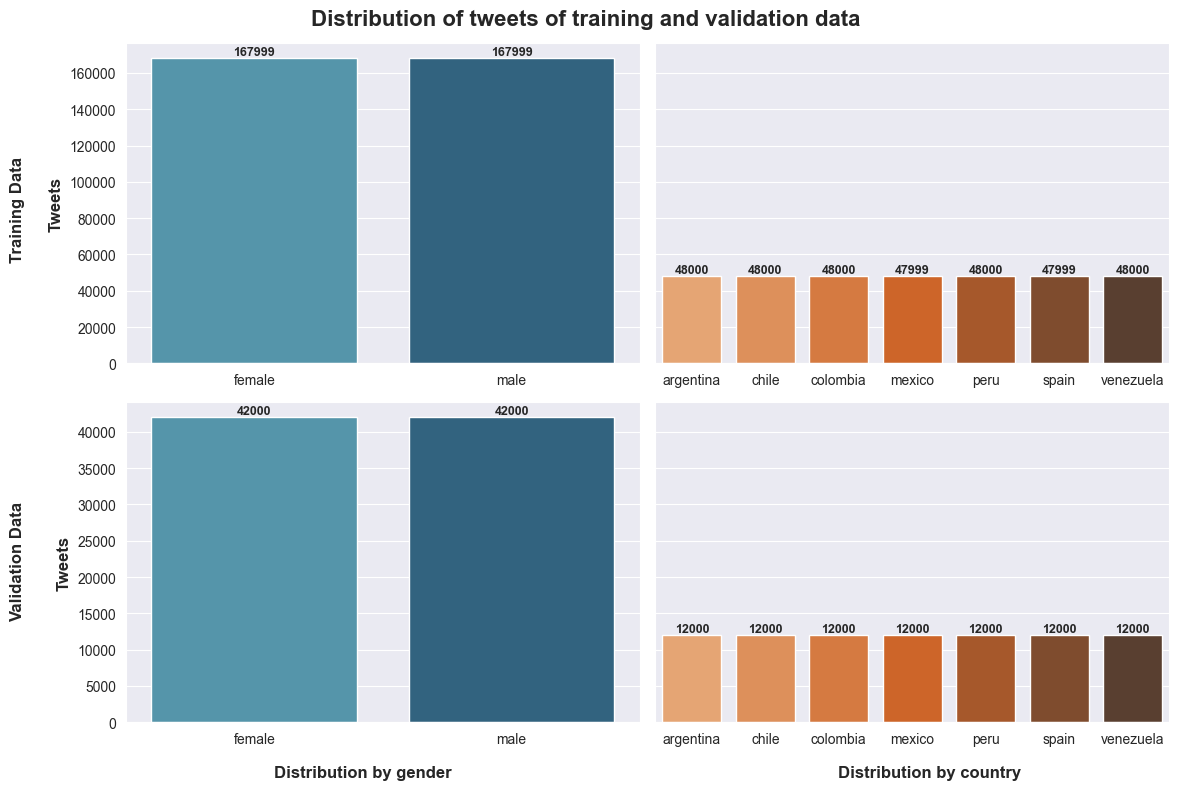

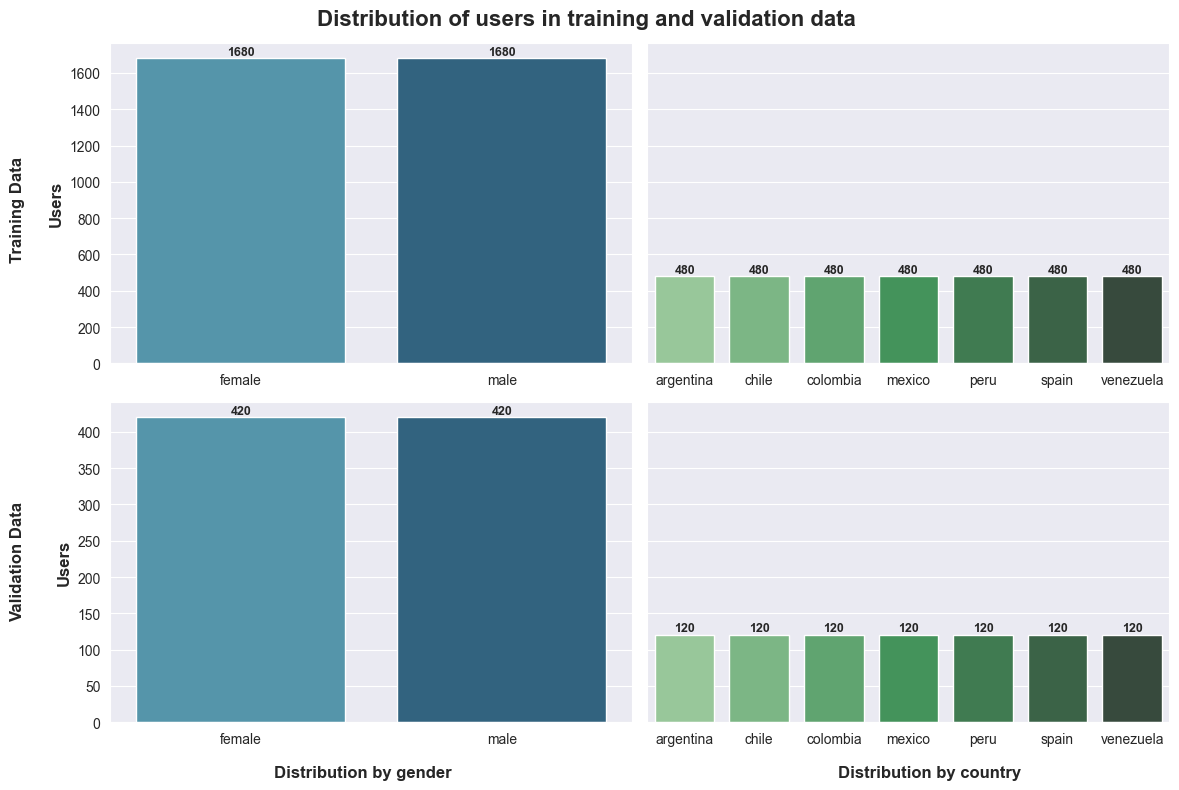

In [5]:
plot_distribution(user_to_tweets_train, user_to_tweets_val, user_to_labels_train, user_to_labels_val, plot_type = 'tweets')
plot_distribution(user_to_tweets_train, user_to_tweets_val, user_to_labels_train, user_to_labels_val, plot_type = 'users')

In [6]:
gender_to_id = {gender: idx for idx, gender in enumerate(sorted(genders))}
country_to_id = {country: idx for idx, country in enumerate(sorted(countries))}

print("Gender Map  :", gender_to_id)
print("Country Map :", country_to_id)

Gender Map  : {'female': 0, 'male': 1}
Country Map : {'argentina': 0, 'chile': 1, 'colombia': 2, 'mexico': 3, 'peru': 4, 'spain': 5, 'venezuela': 6}


In [7]:
class AuthorProfilingDataset(Dataset):
    def __init__(self, user_to_tweets: Dict[str, List[str]], user_to_labels: Optional[Dict[str, Tuple[str, str]]] = None,
                 tokenizer: Callable = None, remove_stopwords: bool = False, stopwords_set: set = None,
                 gender_to_id: dict = None, country_to_id: dict = None, is_test: bool = False):
        """
        Initialize the dataset with user tweets and labels.

        Parameters
        ----------
        user_to_tweets : dict
            Dictionary mapping user IDs to lists of tweets.
        user_to_labels : dict, optional
            Dictionary mapping user IDs to tuples of labels.
        tokenizer : callable, optional
            Tokenizer for text processing. Default is None.
        remove_stopwords : bool, optional
            If True, remove stopwords from the text. Default is False.
        stopwords_set : set, optional
            Set of stopwords to remove. Default is None.
        gender_to_id : dict, optional
            Dictionary mapping genders to IDs. Default is None.
        country_to_id : dict, optional
            Dictionary mapping countries to IDs. Default is None.
        is_test : bool, optional
            If True, the dataset is for testing. Default is False.
        """
        # Initialize the dataset with user tweets and labels.
        self.user_to_tweets = user_to_tweets
        self.user_to_labels = user_to_labels
        self.is_test = is_test
        self.gender_to_id = gender_to_id
        self.country_to_id = country_to_id
        self.id_to_gender = {v: k for k, v in gender_to_id.items()}
        self.id_to_country = {v: k for k, v in country_to_id.items()}

        if not is_test:
            assert user_to_labels is not None, "Labels must be provided for training and validation datasets."

        # Load vocabulary and embeddings.
        self.vocab, self.emb_mat = self.load_vocab_embeddings()
        self.user_ids = list(user_to_tweets.keys())

        # Tokenizer for text processing and additional parameters.
        self.tokenizer = tokenizer if tokenizer else TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)
        self.remove_stopwords = remove_stopwords
        self.stopwords_set = stopwords_set

    @staticmethod
    def load_vocab_embeddings(path: str = 'data/word2vec_col.txt') -> Tuple[dict, np.ndarray]:
        """
        Load vocabulary and embeddings from the file at 'data/word2vec_col.txt'.

        Parameters
        ----------
        path : str
            Path to the file containing word embeddings. Default is 'data/word2vec_col.txt'.
        
        Returns
        -------
        vocab : dict
            Dictionary mapping words to their indices.
        embeddings : np.ndarray
            Array of word embeddings.
        """
        # Load vocabulary and embeddings from the specified file.
        embeddings_list = []
        vocab = {}
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk.
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector.
        vocab['pad'] = 0
        vocab['unk'] = 1
        return vocab, np.vstack(embeddings_list)

    def preprocessed_text(self, text: str) -> List[int]:
        """
        Preprocess the text by tokenizing, converting to lowercase, and removing stopwords. Convert
        the tokens to their corresponding IDs using the vocabulary.

        Parameters
        ----------
        text : str
            Text to be preprocessed.
        
        Returns
        -------
        word_ids : list
            List of word IDs corresponding to the tokens in the text.
        """
        words = self.tokenizer.tokenize(text.lower())
        if self.remove_stopwords:
            words = [word for word in words if word not in self.stopwords_set]
        word_ids = [self.vocab.get(word, self.vocab['unk']) for word in words]
        return word_ids

    def __len__(self) -> int:
        """
        Return the number of users in the dataset.
        """
        return len(self.user_ids)

    def __getitem__(self, index: int) -> Union[Tuple[List[int], int], Tuple[List[int], int, int]]:
        """
        Get the item at the specified index. If the dataset is for testing, return user ID and tweets.
        If the dataset is for training or validation, return user ID, tweets and labels.

        Parameters
        ----------
        index : int
            Index of the item to be retrieved.

        Returns
        -------
        item : tuple
            If is_test is True, returns a tuple of (tweets, user_id).
            If is_test is False, returns a tuple of (tweets, gender_id, country_id).   
        """
        user_id = self.user_ids[index]        # Get user ID.
        tweets = self.user_to_tweets[user_id] # Get tweets for the user.
        tweet_ids_list = [self.preprocessed_text(tweet) or [self.vocab['unk']] for tweet in tweets]

        if self.is_test:
            return tweet_ids_list, user_id

        gender, country = self.user_to_labels[user_id]
        gender_id = self.gender_to_id[gender]
        country_id = self.country_to_id[country]

        return tweet_ids_list, gender_id, country_id

    @staticmethod
    def collate_fn(batch: List[Union[Tuple[List[List[int]], int, int], Tuple[List[List[int]], str]]]
                   ) -> Union[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], Tuple[torch.Tensor, List[str]]]:
        """
        Custom collate function to pad the sequences in the batch and return them as tensors. If the batch
        contains labels, return them as well.

        Parameters
        ----------
        batch : list
            List of tuples containing the data to be collated.

        Returns
        -------
        collated_batch : tuple
            - If the batch contains labels, returns a tuple of padded sequences, gender IDs and country IDs.
            - If the batch does not contain labels, returns a tuple of padded sequences and user IDs.
        """
        pad_value = 0

        if len(batch[0]) == 3: 
            padded_batch, labels_gender, labels_country = [], [], []
            
            max_tweets = max(len(tweets) for tweets, _, _ in batch)
            max_words = max(len(words) for tweets, _, _ in batch for words in tweets)

            for tweets, gender_id, country_id in batch:
                tweet_tensors = [
                    torch.tensor(words + [pad_value] * (max_words - len(words)), dtype = torch.long)
                    for words in tweets
                ]
                while len(tweet_tensors) < max_tweets:
                    tweet_tensors.append(torch.full((max_words,), pad_value, dtype = torch.long))
                padded_batch.append(torch.stack(tweet_tensors))
                labels_gender.append(gender_id)
                labels_country.append(country_id)

            collated_batch = (torch.stack(padded_batch), torch.tensor(labels_gender), torch.tensor(labels_country))
            
            return collated_batch

        else:  
            padded_batch, user_ids = [], []
            max_tweets = max(len(tweets) for tweets, _ in batch)
            max_words = max(len(words) for tweets, _ in batch for words in tweets)

            for tweets, user_id in batch:
                tweet_tensors = [
                    torch.tensor(words + [pad_value] * (max_words - len(words)), dtype = torch.long)
                    for words in tweets
                ]
                while len(tweet_tensors) < max_tweets:
                    tweet_tensors.append(torch.full((max_words,), pad_value, dtype = torch.long))
                padded_batch.append(torch.stack(tweet_tensors))
                user_ids.append(user_id)

            collated_batch = (torch.stack(padded_batch), user_ids)

            return collated_batch

In [8]:
# Create the datasets.
train_dataset = AuthorProfilingDataset(
    user_to_tweets = user_to_tweets_train, user_to_labels = user_to_labels_train, gender_to_id = gender_to_id, country_to_id = country_to_id
)
val_dataset = AuthorProfilingDataset(
    user_to_tweets = user_to_tweets_val, user_to_labels = user_to_labels_val, gender_to_id = gender_to_id, country_to_id = country_to_id
)
test_dataset = AuthorProfilingDataset(
    user_to_tweets = user_to_tweets_test, gender_to_id = gender_to_id, country_to_id = country_to_id, is_test = True
)

# Create the dataloaders.
batch_size = 8
train_dataloader = DataLoader(
    dataset = train_dataset, batch_size = batch_size, shuffle = True, collate_fn = train_dataset.collate_fn)
val_dataloader = DataLoader(
    dataset = val_dataset, batch_size = batch_size, shuffle = False,collate_fn = val_dataset.collate_fn)
test_dataloader = DataLoader( 
    dataset = test_dataset, batch_size = batch_size, shuffle = False, collate_fn = test_dataset.collate_fn)

In [9]:
batch = next(iter(train_dataloader))
print("Train batch shape :", batch[0].shape)
print("Labels shape      :", batch[1].shape)

Train batch shape : torch.Size([8, 100, 35])
Labels shape      : torch.Size([8])


# Model

In [10]:
class Attention(nn.Module):
    def __init__(self, hidden_size: int):
        """
        Attention mechanism. Computes a context-aware weighted average of encoder outputs using a learned context
        vector using the following equations of the paper:
            - Word-level: Eq. (5)-(7)
            - Sentence-level: Eq. (8)-(10)

        Parameters
        ----------
        hidden_size : int
            Dimensionality of the encoder outputs.
        """
        super(Attention, self).__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)            
        self.context_vector = nn.Parameter(torch.randn(hidden_size)) 

    def forward(self, encoder_outputs: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute attention-weighted sum of encoder outputs.

        Parameters
        ----------
        encoder_outputs : torch.Tensor
            Tensor of shape [batch, seq_len, hidden_size] from a BiGRU.

        Returns
        -------
        weighted_output : torch.Tensor
            The weighted sum of encoder outputs, shape [batch, hidden_size].
        attention_weights : torch.Tensor
            Attention weights for each input element, shape [batch, seq_len].
        """
        u = torch.tanh(self.linear(encoder_outputs))  
        attention_scores = torch.matmul(u, self.context_vector)  
        attention_weights = F.softmax(attention_scores, dim = 1) 
        weighted_output = torch.sum(encoder_outputs * attention_weights.unsqueeze(-1), dim = 1) 
        return weighted_output, attention_weights

class HierarchicalAttentionNet(nn.Module):
    """
    Hierarchical Attention Network for Author Profiling. This model uses a two-level attention mechanism to
    process tweets from users. The first level applies attention to the words in each tweet, and the second
    level applies attention to the tweets of each user. The final output is a classification of the user into
    one of the countries. Architecture components:
        - Word-level BiGRU + attention (per tweet) — Eq. (1)-(7)
        - Tweet-level BiGRU + attention (per user) — Eq. (1)-(10)
        - Final classifier — Eq. (11)

    Parameters
    ----------
    emb_dim : int
        Dimensionality of word embeddings.
    word_hidden_size : int
        Hidden size of the word-level GRU (per direction).
    tweet_hidden_size : int
        Hidden size of the tweet-level GRU (per direction).
    num_classes : int
        Number of output classes (e.g., countries).
    emb_matrix : np.ndarray
        Pretrained embedding matrix to initialize the embedding layer.
    """
    def __init__(self, emb_dim: int, word_hidden_size: int, tweet_hidden_size: int, num_classes_gender: int,
                 num_classes_country: int, emb_matrix: np.ndarray):
        super().__init__()
        self.dropout = nn.Dropout(0.15)

        # Embedding layer using pretrained word2vec.
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype = torch.float32),
            freeze = False # Set to True if you want to freeze the embeddings.
        )

        # Word-level BiGRU encoder (per tweet).
        self.word_gru     = nn.GRU(
            input_size    = emb_dim,
            hidden_size   = word_hidden_size,
            batch_first   = True,
            bidirectional = True
        )

        # Word-level attention.
        self.word_attention = Attention(2 * word_hidden_size)

        # Tweet-level BiGRU encoder (per user).
        self.tweet_gru    = nn.GRU(
            input_size    = 2 * word_hidden_size,
            hidden_size   = tweet_hidden_size,
            batch_first   = True,
            bidirectional = True
        )

        # Tweet-level attention.
        self.tweet_attention = Attention(2 * tweet_hidden_size)

        # Final classifier.
        self.classifier_gender = nn.Linear(2 * tweet_hidden_size, num_classes_gender)
        self.classifier_country = nn.Linear(2 * tweet_hidden_size, num_classes_country)

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the Hierarchical Attention Network.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape [batch_size, max_tweets, max_words], where each entry is a word index.
            input: x \in N^{B x T x W}  # batch_size x tweets_per_user x words_per_tweet

        Returns
        -------
        logits_gender : torch.Tensor
            Logits for gender classification, shape [batch_size, num_classes_gender].
        logits_country : torch.Tensor
            Logits for country classification, shape [batch_size, num_classes_country].
        word_attn_weights : torch.Tensor
            Attention weights at the word level, shape [batch_size * max_tweets, max_words].
        tweet_attn_weights : torch.Tensor
            Attention weights at the tweet level, shape [batch_size, max_tweets].
        """
        batch_size, num_tweets, num_words = x.size()

        # Flatten batch and tweets to process all tweets in parallel
        x = x.view(-1, num_words) 
        x = self.embedding(x) # → (B*T, W, emb_dim)

        word_output, _ = self.word_gru(x)                                              # Encode words using BiGRU (B*T, W, 2H_word).
        tweet_representations, word_attn_weights = self.word_attention(word_output)    # Word-level attention to get tweet representation # (B*T, 2H_word).
        tweet_representations = tweet_representations.view(batch_size, num_tweets, -1) # Reshape.
        tweet_output, _ = self.tweet_gru(tweet_representations)                        # Encode tweets using BiGRU (B, T, 2H_tweet).
        doc_representation, tweet_attn_weights = self.tweet_attention(tweet_output)    # Tweet-level attention to get user/document representation (B, 2H_tweet).

        # Apply the classifier.
        doc_representation = self.dropout(doc_representation)        # Apply dropout (B, 2H_tweet).
        logits_gender = self.classifier_gender(doc_representation)   # (B, num_genders)
        logits_country = self.classifier_country(doc_representation) # (B, num_countries)

        return logits_gender, logits_country, word_attn_weights, tweet_attn_weights

In [11]:
class Trainer:
    def __init__(
            self, model: nn.Module, epochs: int, train_dataset: Dataset, train_dataloader: DataLoader,
            val_dataloader: DataLoader, device: str, patience: int = 3, lambdas: Tuple[float, float] = (0.5, 0.5),
            lr: float = 1e-3, lr_patience: int = 3, weight_decay: float = 1e-4, lr_factor: float = 0.1,
            checkpoint_path: str = 'trained_model', checkpoint_filename: str = 'checkpoint.pth',
            model_init_args: dict = None
    ):
        # Initialize the trainer.
        self.model            = model.to(device)
        self.epochs           = epochs
        self.train_dataset    = train_dataset
        self.train_dataloader = train_dataloader
        self.val_dataloader   = val_dataloader
        self.device           = device
        self.patience         = patience
        self.lambdas          = lambdas
        self.model_init_args  = model_init_args

        # Checkpoint parameters.
        self.checkpoint_path     = checkpoint_path
        self.checkpoint_filename = checkpoint_filename
        self.best_model_filename = (self.checkpoint_filename).replace('.pth', '_best.pth')

        # Initialize the best model parameters.
        self.best_joint_accuracy = 0.0 # Best joint accuracy.
        self.best_epoch          = 0   # Best epoch.
        self.best_time           = 0.0 # Best time.

        # Initialize the training history.
        self.train_loss_history       = []   # Training loss history.
        self.val_loss_history         = []   # Validation loss history.
        self.joint_accuracy_history   = []   # Joint accuracy history.
        self.accuracy_gender_history  = []   # Accuracy history for gender classification.
        self.accuracy_country_history = []   # Accuracy history for country classification.
        self.n_no_improvement         = 0    # Number of epochs without improvement.
        self.best_state_dict          = None # Store the best model state dict.

        # Optimizer.
        self.optimizer   = optim.Adam(           
            params       = model.parameters(), # parameters to optimize.
            lr           = lr,                 # learning rate.
            weight_decay = weight_decay,       # weight decay.
            betas        = (0.9, 0.999)        # betas for the optimizer.
        )

        # Scheduler.
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau( 
            optimizer  = self.optimizer, # optimizer to adjust.
            mode       = 'min',          # mode (min means reduce when the quantity monitored has stopped decreasing).
            patience   = lr_patience,    # patience (number of epochs with no improvement after which learning rate will be reduced).
            factor     = lr_factor       # factor by which the learning rate will be reduced. new_lr = lr * factor.
        )

        # Loss functions for classification.
        self.criterion_gender = nn.CrossEntropyLoss()  # Loss for gender classification.
        self.criterion_country = nn.CrossEntropyLoss() # Loss for country classification.

    def loss_function(self, logits_gender: torch.Tensor, logits_country: torch.Tensor,
                      labels_gender: torch.Tensor, labels_country: torch.Tensor) -> torch.Tensor:
        loss_gender = self.criterion_gender(logits_gender, labels_gender)     # Loss for gender classification.
        loss_country = self.criterion_country(logits_country, labels_country) # Loss for country classification.
    
        return self.lambdas[0] * loss_gender + self.lambdas[1] * loss_country # Weighted sum of the losses.

    def eval_model(self, dataloader: DataLoader) -> dict:
        self.model.eval() # Set the model to evaluation mode.
        predictions_gender, predictions_country = [], [] # List to store the predictions.
        targets_gender, targets_country = [], []         # List to store the targets.
        scores_gender, scores_country = [], []           # List to store the scores.
        losses = []                                      # List to store the losses.
          
        with torch.no_grad():          
            # Iterate over the batches.
            for inputs, labels_gender, labels_country in tqdm(dataloader, desc = 'Evaluation... ', colour = 'blue'):
                torch.cuda.empty_cache() # Clear the cache.
                inputs, labels_gender, labels_country = inputs.to(self.device), labels_gender.to(self.device), labels_country.to(self.device)
    
                # Forward pass.
                logits_gender, logits_country, word_attn_weights, tweet_attn_weights = self.model(inputs) # Forward pass.

                # Calculate the loss for the batch.
                loss_per_batch = self.loss_function(logits_gender, logits_country, labels_gender, labels_country) # Loss for country classification.
                losses.append(loss_per_batch.item())

                # Predictions and targets.
                pred_gender = logits_gender.argmax(dim = 1)   # Predicted class for gender.
                pred_country = logits_country.argmax(dim = 1) # Predicted class for country.

                predictions_gender += pred_gender.cpu().tolist()
                predictions_country += pred_country.cpu().tolist()
                targets_gender += labels_gender.cpu().tolist()
                targets_country += labels_country.cpu().tolist()

                # Probabilities using softmax (for score/confidence tracking)
                probs_gender = torch.softmax(logits_gender, dim = 1)
                probs_country = torch.softmax(logits_country, dim = 1)

                scores_gender += probs_gender[torch.arange(len(pred_gender)), pred_gender].cpu().tolist()
                scores_country += probs_country[torch.arange(len(pred_country)), pred_country].cpu().tolist()

            # Convert predictions and targets to tensors for joint accuracy calculation.
            predictions_gender_tensor = torch.tensor(predictions_gender)
            predictions_country_tensor = torch.tensor(predictions_country)
            targets_gender_tensor = torch.tensor(targets_gender)
            targets_country_tensor = torch.tensor(targets_country)

            accuracy_gender = (predictions_gender_tensor == targets_gender_tensor).float().mean().item()
            accuracy_country = (predictions_country_tensor == targets_country_tensor).float().mean().item()
            joint_correct = (predictions_gender_tensor == targets_gender_tensor) & (predictions_country_tensor == targets_country_tensor)
            joint_accuracy = joint_correct.float().mean().item()

            return {
                'loss_val'         : np.mean(losses),
                'joint_accuracy'   : joint_accuracy,
                'accuracy_gender'  : accuracy_gender,
                'accuracy_country' : accuracy_country,
                'targets_gender'   : targets_gender,
                'preds_gender'     : predictions_gender,
                'targets_country'  : targets_country,
                'preds_country'    : predictions_country,
                'scores_gender'    : scores_gender,
                'scores_country'   : scores_country,  
                }

    def train(self):
        """
        Train the model.
        """
        start_time = time.time() # Start time of the training.

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            loss_train = 0
            epoch_time = time.time() # Start time of the epoch.
    
            for inputs, labels_gender, labels_country in tqdm(self.train_dataloader, desc = 'Training... ', colour = 'green'):
                torch.cuda.empty_cache()   # Clear the cache.       
                self.optimizer.zero_grad() # Zero the gradients.
    
                inputs, labels_gender, labels_country = inputs.to(self.device), labels_gender.to(self.device), labels_country.to(self.device)
    
                logits_gender, logits_country, word_attn_weights, tweet_attn_weights = self.model(inputs) # Forward pass.
                
                # Calculate the loss for the batch.
                loss = self.loss_function(logits_gender, logits_country, labels_gender, labels_country) # Loss for country classification.
                
                # Backward pass and optimization.
                loss.backward()
                self.optimizer.step()
                loss_train += loss.item()
    
            # Average loss for the epoch.
            avg_loss = loss_train / len(self.train_dataloader)
    
            # Evaluate the model on the validation set.
            val_results = self.eval_model(self.val_dataloader)

            # Store the results.
            self.train_loss_history.append(avg_loss)
            self.val_loss_history.append(val_results['loss_val'])
            self.joint_accuracy_history.append(val_results['joint_accuracy'])
            self.accuracy_gender_history.append(val_results['accuracy_gender'])
            self.accuracy_country_history.append(val_results['accuracy_country'])
    
            # Sum of F1 scores to determine the best model.
            is_improvement = val_results['joint_accuracy'] > self.best_joint_accuracy
            
            if is_improvement:
                self.best_joint_accuracy = val_results['joint_accuracy']
                self.best_time = time.time() - start_time
                self.best_epoch = epoch
                self.best_state_dict = self.model.state_dict()
                self.n_no_improvement = 0
            else:
                self.n_no_improvement += 1

            # Save checkpoint.
            elapsed_time = time.time() - start_time # Elapsed time since the start of training.
            self.save_checkpoint(
                state = {
                    # This epoch information.
                    'epoch'                   : epoch,
                    'state_dict'              : self.model.state_dict(),
                    'loss_train'              : avg_loss,
                    'loss_val'                : val_results['loss_val'],
                    'joint_accuracy'          : val_results['joint_accuracy'],
                    'accuracy_gender'         : val_results['accuracy_gender'],
                    'accuracy_country'        : val_results['accuracy_country'],
                    'elapsed_time'            : elapsed_time,
                    # Best information.
                    'best_joint_accuracy'     : self.best_joint_accuracy,
                    'best_epoch'              : self.best_epoch,
                    'best_time'               : self.best_time,
                    'best_state_dict'         : self.best_state_dict,
                    # History information.
                    'train_loss_history'      : self.train_loss_history,
                    'val_loss_history'        : self.val_loss_history,
                    'joint_accuracy_history'  : self.joint_accuracy_history,
                    'accuracy_gender_history' : self.accuracy_gender_history,
                    'accuracy_country_history': self.accuracy_country_history,
                },
                is_best = is_improvement
            )

            # Early stopping.
            if self.n_no_improvement >= self.patience:
                tqdm.write(f"{Fore.RED}Early stopping triggered at epoch {epoch}!{Style.RESET_ALL} due to no improvement.")
                break
            elif loss_train < 1e-5:
                tqdm.write(f"{Fore.RED}Loss is too low, stopping training!{Style.RESET_ALL}")
                break
    
            # Print the results.
            tqdm.write(f"{Style.BRIGHT}{Fore.CYAN} Epoch{epoch:>3}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Train loss: {Fore.GREEN}{avg_loss:.4f}{Style.RESET_ALL} | "
                       f"Val Loss: {Fore.YELLOW}{val_results['loss_val']:.4f}{Style.RESET_ALL} | "
                       f"Acc gender: {Fore.MAGENTA}{val_results['accuracy_gender']:.4f}{Style.RESET_ALL} | "
                       f"Acc country: {Fore.MAGENTA}{val_results['accuracy_country']:.4f}{Style.RESET_ALL} | "
                       f"Joint Acc: {Fore.RED}{val_results['joint_accuracy']:.4f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {elapsed_time:.2f} s")
            
        print(f"\n{Style.BRIGHT}--- Total Training Time: {elapsed_time:.2f} seconds ---{Style.RESET_ALL}")
        print(f"Best model achieved at epoch {self.best_epoch} with Final Accuracy = {self.best_joint_accuracy:.4f}")

    def save_checkpoint(self, state: dict, is_best: bool) -> None:
        """
        Save a checkpoint of the model, including the state dictionary, training metadata,
        optimizer state, and the initialization parameters used to construct the model.

        Parameters
        ----------
        state : dict
            Dictionary with the model state, best model state, loss histories, and optimizer state.
        is_best : bool
            If True, also save the model as the best checkpoint.
        """
        if not os.path.exists(self.checkpoint_path):
            os.makedirs(self.checkpoint_path, exist_ok = True)

        # Save the model initialization arguments.
        state['model_init_args'] = self.model_init_args or {}

        if is_best:
            state['best_model_state_dict'] = self.model.state_dict()

        filepath = os.path.join(self.checkpoint_path, self.checkpoint_filename)
        torch.save(state, filepath)

        if is_best:
            best_path = os.path.join(self.checkpoint_path, self.best_model_filename)
            torch.save({'best_model_state_dict': self.model.state_dict(),
                        'model_init_args': self.model_init_args}, best_path)

    @classmethod
    def load_model_from_checkpoint(cls,
                                   checkpoint_path: str = 'trained_model/checkpoint.pth',
                                   train_dataset: Dataset = None,
                                   device: str = 'cpu') -> 'Trainer':
        # Cargar checkpoint completo para obtener args y métricas
        full_checkpoint = torch.load(checkpoint_path, map_location = torch.device(device), weights_only = False)
        model_args = full_checkpoint['model_init_args']

        # Cargar pesos del mejor modelo desde archivo separado
        best_model_path = checkpoint_path.replace('.pth', '_best.pth')
        if os.path.exists(best_model_path):
            best_checkpoint = torch.load(best_model_path, map_location = torch.device(device), weights_only = False)
            state_dict = best_checkpoint['best_model_state_dict']
            print(f"Best model loaded.")
        else:
            state_dict = full_checkpoint['state_dict']
            print(f"Checkpoint loaded.")
        
        model = HierarchicalAttentionNet(**model_args)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()

        trainer = cls(
            model            = model,
            model_init_args  = model_args,
            epochs           = 0,
            train_dataset    = train_dataset,
            train_dataloader = None,
            val_dataloader   = None,
            device           = device,
            patience         = 0
        )

        trainer.full_checkpoint = full_checkpoint
        return trainer
    
    def print_training_summary(self):
        checkpoint = self.full_checkpoint

        epochs = checkpoint.get('epoch', None)
        best_epoch = checkpoint.get('best_epoch', None)
        best_time = checkpoint.get('best_time', None)
        best_joint_acc = checkpoint.get('best_joint_accuracy', None)
        acc_gender = checkpoint.get('accuracy_gender', None)
        acc_country = checkpoint.get('accuracy_country', None)
        loss_train = checkpoint.get('loss_train', None)
        loss_val = checkpoint.get('loss_val', None)
        total_time = checkpoint.get('elapsed_time', None)

        print("TRAINING SUMMARY:")
        print("─"* 60)
        print(f"Total epochs        : {epochs}")
        print(f"Best epoch          : {best_epoch}")
        print(f"Best joint accuracy : {best_joint_acc:.4f}")
        print(f"Gender accuracy     : {acc_gender:.4f}")
        print(f"Country accuracy    : {acc_country:.4f}")
        print(f"Loss (train)        : {loss_train:.4f}")
        print(f"Loss (val)          : {loss_val:.4f}")
        print(f"Best time           : {best_time:.2f} s")
        print(f"Total training time : {total_time:.2f} s")
        print("─"* 60)

    def plot_loss(self):
        checkpoint = self.full_checkpoint
        train_losses = checkpoint.get('train_loss_history', [])
        val_losses = checkpoint.get('val_loss_history', [])
        best_epoch = checkpoint.get('best_epoch', None)

        if not train_losses or not val_losses:
            print("No history of training or validation loss found.")
            return

        epochs = list(range(1, len(train_losses) + 1))
        fig, ax = plt.subplots(figsize = (10,6))
        ax.plot(epochs, train_losses, marker = 'o', color = '#1f77b4', label = 'Train Loss')
        ax.plot(epochs, val_losses, marker = 's', color = '#ff7f0e', label = 'Validation Loss')
        ax.axvline(best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {best_epoch}")    
        ax.set_xlabel("Epoch", fontsize = 12)
        ax.set_ylabel("Loss", fontsize = 12)
        ax.set_title("Loss Evolution per Epoch", fontsize = 14, weight = 'bold')
        ax.set_ylim(0, max(max(train_losses), max(val_losses)) * 1.1)
        ax.set_xlim(0, len(train_losses) + 1)
        ax.set_xticks(epochs)
        ax.set_xticklabels(epochs)
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
    def plot_accuracy(self):
        checkpoint = self.full_checkpoint
        joint_acc = checkpoint.get('joint_accuracy_history', [])
        acc_gender = checkpoint.get('accuracy_gender_history', [])
        acc_country = checkpoint.get('accuracy_country_history', [])
        best_epoch = checkpoint.get('best_epoch', None)
        
        if not joint_acc or not acc_gender or not acc_country:
            print("No history of accuracy found.")
            return

        epochs = list(range(1, len(joint_acc) + 1))
        fig, ax = plt.subplots(figsize = (10,6))
        ax.plot(epochs, joint_acc, marker = '*', label = 'Joint Accuracy', linestyle = '--', linewidth = 2.5, color = '#d62728')
        ax.plot(epochs, acc_gender, marker = 'o', label = 'Accuracy Gender', color = '#1f77b4')
        ax.plot(epochs, acc_country, marker = '^', label = 'Accuracy Country', color = '#2ca02c')
        ax.axvline(best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {best_epoch}")    
        ax.set_title("Accuracy Evolution per Epoch", fontsize = 14, weight = 'bold')
        ax.set_xlabel("Epoch", fontsize = 12)
        ax.set_ylabel("Accuracy", fontsize = 12)
        ax.legend()
        ax.grid(True)
        ax.set_ylim(0.0, 1.0)
        plt.tight_layout()
        plt.show()

# Train

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_params = {
    'emb_dim'             : 100,
    'word_hidden_size'    : 128,
    'tweet_hidden_size'   : 128,
    'num_classes_gender'  : len(gender_to_id),
    'num_classes_country' : len(country_to_id),
    'emb_matrix'          : train_dataset.emb_mat
}

# Create the model.
model_HAN = HierarchicalAttentionNet(**model_params).to(device)

# Create the trainer.
trainer_HAN = Trainer(
    model               = model_HAN,
    epochs              = 25,
    train_dataset       = train_dataset,
    train_dataloader    = train_dataloader,
    val_dataloader      = val_dataloader,
    device              = device,
    patience            = 10,
    lambdas             = (0.6, 0.4),
    lr                  = 1e-4,
    lr_patience         = 3,
    weight_decay        = 1e-4,
    lr_factor           = 0.1,
    checkpoint_path     = 'trained_model',
    checkpoint_filename = 'checkpoint.pth',
    model_init_args     = model_params
)

# Train the model.
trainer_HAN.train()

Evaluation... : 100%|██████████| 105/105 [00:10<00:00, 10.33it/s]


 Epoch  1/25  ➤ Train loss: 1.1198 | Val Loss: 1.0493 | Acc gender: 0.6643 | Acc country: 0.3548 | Joint Acc: 0.2202 | Epoch Time: 158.24 s | Total Time: 150.07 s


Evaluation... : 100%|██████████| 105/105 [00:10<00:00, 10.39it/s]


 Epoch  2/25  ➤ Train loss: 0.9515 | Val Loss: 0.8771 | Acc gender: 0.6583 | Acc country: 0.6095 | Joint Acc: 0.3821 | Epoch Time: 152.14 s | Total Time: 302.00 s


Evaluation... : 100%|██████████| 105/105 [00:09<00:00, 10.53it/s]


...

 Epoch 23/25  ➤ Train loss: 0.1992 | Val Loss: 0.7431 | Acc gender: 0.6964 | Acc country: 0.8143 | Joint Acc: 0.5595 | Epoch Time: 148.24 s | Total Time: 3436.36 s


Evaluation... : 100%|██████████| 105/105 [00:10<00:00, 10.42it/s]


 Epoch 24/25  ➤ Train loss: 0.1709 | Val Loss: 0.7225 | Acc gender: 0.7429 | Acc country: 0.8107 | Joint Acc: 0.6000 | Epoch Time: 147.57 s | Total Time: 3583.72 s


Evaluation... : 100%|██████████| 105/105 [00:10<00:00, 10.37it/s]


 Epoch 25/25  ➤ Train loss: 0.1249 | Val Loss: 0.8203 | Acc gender: 0.7369 | Acc country: 0.8167 | Joint Acc: 0.5976 | Epoch Time: 147.13 s | Total Time: 3731.05 s

--- Total Training Time: 3731.05 seconds ---
Best model achieved at epoch 18 with Final Accuracy = 0.6036


In [13]:
# Cargar el modelo directamente desde archivo
trainer = Trainer.load_model_from_checkpoint('trained_model/checkpoint.pth', device = device, train_dataset = train_dataset)
model = trainer.model
model.eval()

Best model loaded.


HierarchicalAttentionNet(
  (dropout): Dropout(p=0.15, inplace=False)
  (embedding): Embedding(973267, 100)
  (word_gru): GRU(100, 128, batch_first=True, bidirectional=True)
  (word_attention): Attention(
    (linear): Linear(in_features=256, out_features=256, bias=True)
  )
  (tweet_gru): GRU(256, 128, batch_first=True, bidirectional=True)
  (tweet_attention): Attention(
    (linear): Linear(in_features=256, out_features=256, bias=True)
  )
  (classifier_gender): Linear(in_features=256, out_features=2, bias=True)
  (classifier_country): Linear(in_features=256, out_features=7, bias=True)
)

TRAINING SUMMARY:
────────────────────────────────────────────────────────────
Total epochs        : 25
Best epoch          : 18
Best joint accuracy : 0.6036
Gender accuracy     : 0.7369
Country accuracy    : 0.8167
Loss (train)        : 0.1249
Loss (val)          : 0.8203
Best time           : 2696.16 s
Total training time : 3731.05 s
────────────────────────────────────────────────────────────


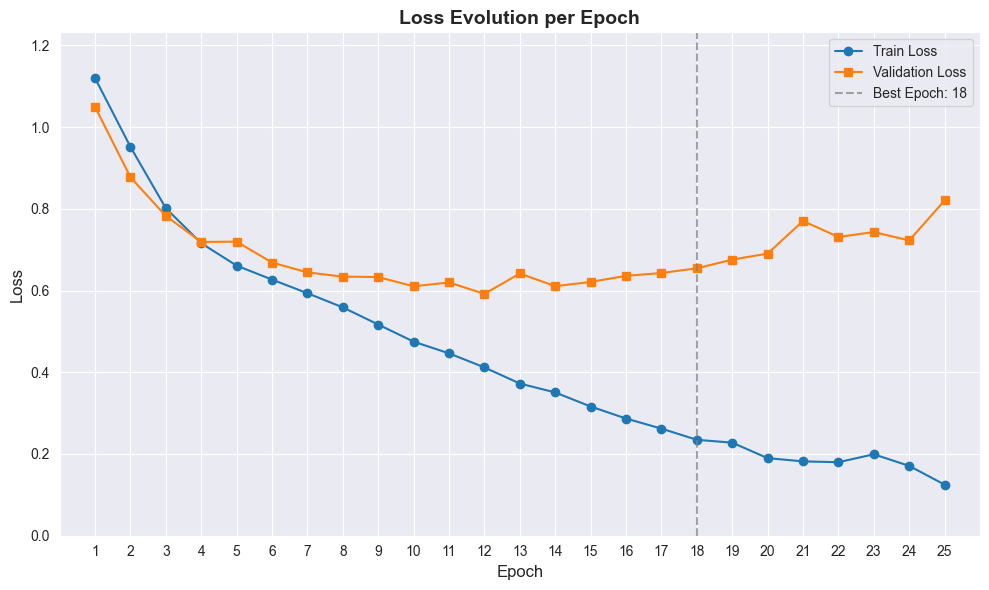

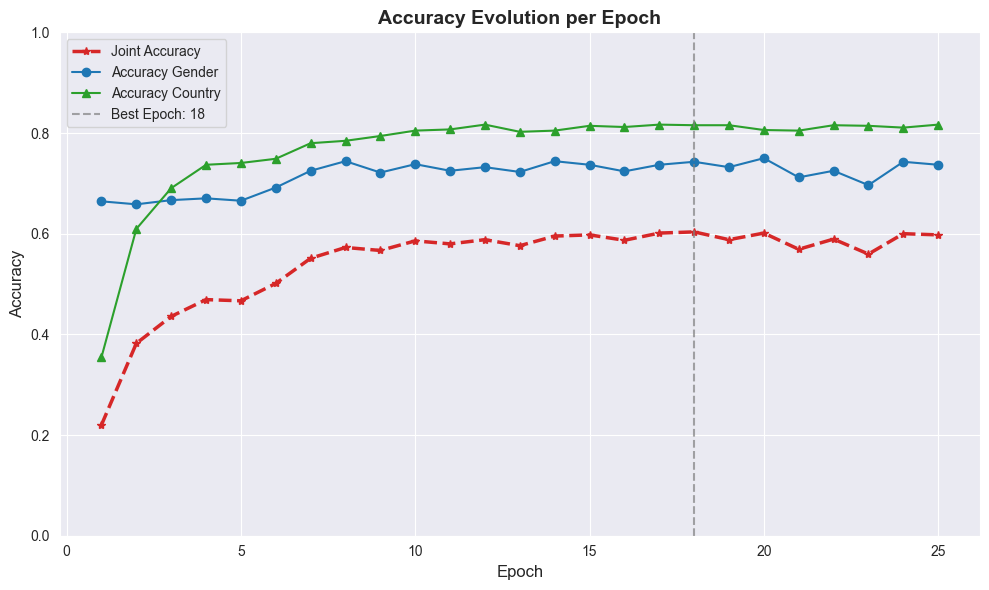

In [14]:
trainer.print_training_summary()
trainer.plot_loss()
trainer.plot_accuracy()

# Results

Evaluating on Evaluation Set:


Evaluation... : 100%|██████████| 105/105 [00:09<00:00, 10.52it/s]


Loss             : 0.6579
Joint Accuracy   : 0.6036
Accuracy Gender  : 0.7429
Accuracy Country : 0.8155

 Classification Report (Gender):
              precision    recall  f1-score   support

      female       0.74      0.75      0.74       420
        male       0.74      0.74      0.74       420

    accuracy                           0.74       840
   macro avg       0.74      0.74      0.74       840
weighted avg       0.74      0.74      0.74       840


 Classification Report (Country):
              precision    recall  f1-score   support

   argentina       0.79      0.83      0.81       120
       chile       0.85      0.88      0.87       120
    colombia       0.81      0.78      0.80       120
      mexico       0.83      0.84      0.84       120
        peru       0.83      0.74      0.78       120
       spain       0.74      0.84      0.79       120
   venezuela       0.87      0.78      0.82       120

    accuracy                           0.82       840
   macro avg

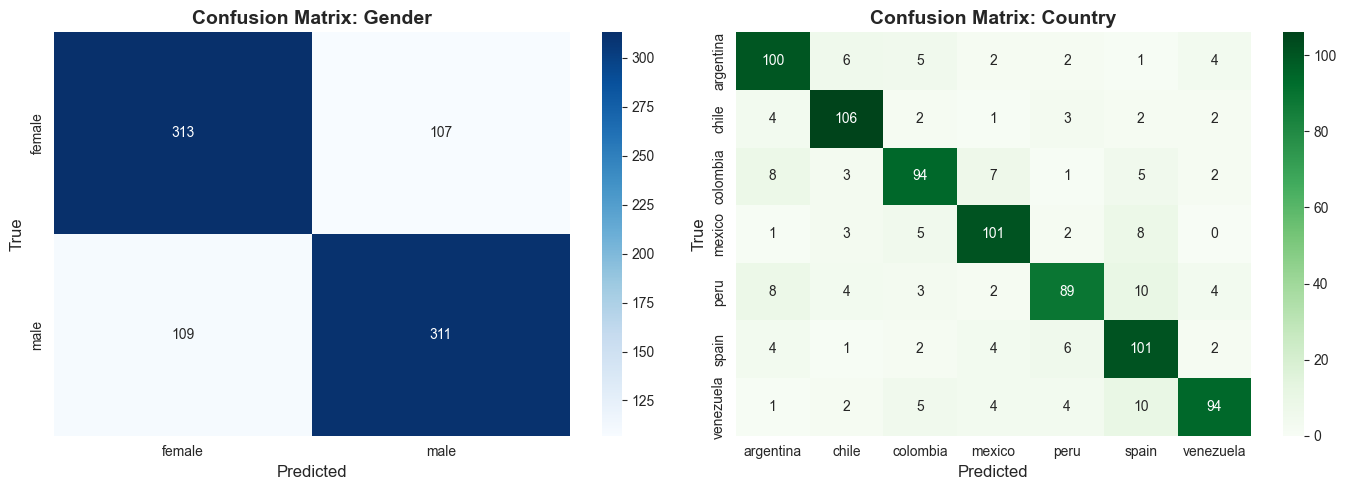

In [15]:
class Evaluation:
    @staticmethod
    def plot_confusion_matrices(y_true_gender: List[int], y_pred_gender: List[int], labels_gender: List[str],
                                y_true_country: List[int], y_pred_country: List[int], labels_country: List[str]) -> None:
        """
        Display side-by-side confusion matrices for gender and country classification.

        Parameters
        ----------
        y_true_gender : list or array
            True gender labels.
        y_pred_gender : list or array
            Predicted gender labels.
        labels_gender : list of str
            Class names for gender.
        y_true_country : list or array
            True country labels.
        y_pred_country : list or array
            Predicted country labels.
        labels_country : list of str
            Class names for country.
        """
        fig, axes = plt.subplots(1, 2, figsize = (14, 5))

        # Gender confusion matrix
        cm_gender = confusion_matrix(y_true_gender, y_pred_gender)
        sns.heatmap(cm_gender, annot = True, fmt = 'd', cmap = 'Blues',
                    xticklabels = labels_gender, yticklabels = labels_gender, ax = axes[0])
        axes[0].set_title("Confusion Matrix: Gender", fontsize = 14, weight = 'bold')
        axes[0].set_xlabel("Predicted", fontsize = 12)
        axes[0].set_ylabel("True", fontsize = 12)

        # Country confusion matrix
        cm_country = confusion_matrix(y_true_country, y_pred_country)
        sns.heatmap(cm_country, annot = True, fmt = 'd', cmap = 'Greens',
                    xticklabels = labels_country, yticklabels = labels_country, ax = axes[1])
        axes[1].set_title("Confusion Matrix: Country", fontsize = 14, weight = 'bold')
        axes[1].set_xlabel("Predicted", fontsize = 12)
        axes[1].set_ylabel("True", fontsize = 12)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def evaluate_dataset(trainer: Trainer, dataloader: DataLoader) -> dict:
        """
        Evaluates the model on a given Validation dataloader and prints summary of accuracy,
        classification reports, and confusion matrices.

        Parameters
        ----------
        trainer : Trainer
            The Trainer object containing the model and evaluation methods.
        dataloader : DataLoader
            The DataLoader object for the dataset to be evaluated.

        Returns
        -------
        results : dict
            A dictionary containing the evaluation results, including loss, accuracy, and predictions.
        """
        print(f"Evaluating on Evaluation Set:")
        results = trainer.eval_model(dataloader)

        # Print metrics
        print(f"Loss             : {results['loss_val']:.4f}")
        print(f"Joint Accuracy   : {results['joint_accuracy']:.4f}")
        print(f"Accuracy Gender  : {results['accuracy_gender']:.4f}")
        print(f"Accuracy Country : {results['accuracy_country']:.4f}")

        # Recover class labels
        labels_gender = [label for label, _ in sorted(trainer.train_dataset.gender_to_id.items(), key = lambda x: x[1])]
        labels_country = [label for label, _ in sorted(trainer.train_dataset.country_to_id.items(), key = lambda x: x[1])]

        print("\n Classification Report (Gender):")
        print(classification_report(results['targets_gender'], results['preds_gender'], target_names = labels_gender))

        print("\n Classification Report (Country):")
        print(classification_report(results['targets_country'], results['preds_country'], target_names = labels_country))

        Evaluation.plot_confusion_matrices(
            results['targets_gender'], results['preds_gender'], labels_gender,
            results['targets_country'], results['preds_country'], labels_country
        )

        return results

results = Evaluation.evaluate_dataset(trainer, val_dataloader)

# Predictions

In [16]:
class TestPredictor:
    def __init__(self, trainer: Trainer, dataset: Dataset, dataloader: DataLoader):
        """
        Initialize the TestPredictor.

        Parameters
        ----------
        trainer : Trainer
            The Trainer object containing the model and evaluation methods.
        dataset : Dataset
            The Dataset object for the dataset to be evaluated.
        dataloader : DataLoader
            The DataLoader object for the dataset to be evaluated.
        """
        self.model = trainer.model
        self.dataset = dataset
        self.dataloader = dataloader
        self.device = trainer.device
        self.id_to_gender = dataset.id_to_gender
        self.id_to_country = dataset.id_to_country
        self.predictions = self.predict()
        self.user_id_order = self.load_test_user_order() # Load the user ID order from the truth file.

    def predict(self) -> List[Tuple[str, str]]:
        """
        Predict method to generate predictions for the test dataset.

        Returns
        -------
        predictions : list of tuples
            A list of tuples containing user IDs and their predicted labels.
        """
        self.model.eval()
        predictions = []

        with torch.no_grad():
            # Iterate over the batches.
            for inputs, user_ids in tqdm(self.dataloader, desc = "Predicting...", colour = "cyan"):
                inputs = inputs.to(self.device)

                # Forward pass.
                logits_gender, logits_country, _, _ = self.model(inputs)

                # Predictions and targets.
                predictions_gender = logits_gender.argmax(dim = 1).cpu().tolist()     # Predicted class for gender.
                predictions_countries = logits_country.argmax(dim = 1).cpu().tolist() # Predicted class for country.

                for user_id, pred_gender, pred_country in zip(user_ids, predictions_gender, predictions_countries):
                    label_gender = self.id_to_gender[pred_gender]
                    label_country = self.id_to_country[pred_country]
                    predictions.append((user_id, f"{label_gender}:::{label_country}"))

        return predictions
    
    def load_test_user_order(self, truth_file_path: str = 'data/es_test/truth_order.txt') -> List[str]:
        user_ids = []
        with open(truth_file_path, 'r', encoding = 'utf-8') as f:
            for line in f:
                user_id = line.strip().split(":::")[0]
                user_ids.append(user_id)
        return user_ids

    def save_predictions_csv(self, output_file: str) -> None:
        """
        Save the predictions to a CSV file, ordered according to user_id_order.

        Parameters
        ----------
        output_file : str
            The path to the output CSV file.
        """
        # Convert predictions to a dictionary for fast lookup
        prediction_dict = {user_id: label for user_id, label in self.predictions}

        with open(output_file, mode = 'w', newline = '', encoding = 'utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(["Id", "Gender:::Nationality"])
            for user_id in self.user_id_order:
                label = prediction_dict.get(user_id, "_:::_") # Fallback in case of mismatch
                writer.writerow([user_id, label])

In [17]:
output_file = "predictions.csv"
predictor = TestPredictor(
    trainer    = trainer,
    dataset    = test_dataset,
    dataloader = test_dataloader,
)
predictor.save_predictions_csv(output_file = output_file)

Predicting...: 100%|██████████| 350/350 [00:34<00:00, 10.28it/s]


In [18]:
def load_predictions_from_csv(output_file: str) -> Tuple[Dict[str, Tuple[str, str]], pd.DataFrame]:
    user_to_label_test = {}
    with open(output_file, mode = 'r', encoding = 'utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            gender, country = row["Gender:::Nationality"].split(":::")
            user_to_label_test[row["Id"]] = (gender, country)

    # Convertir a dataframe
    df_pred = pd.DataFrame.from_dict(user_to_label_test, orient = 'index', columns = ['gender', 'country'])
    
    # Opcional: reiniciar el índice para que 'user_id' sea una columna
    df_pred.reset_index(inplace = True)
    df_pred.rename(columns = {'index': 'user_id'}, inplace = True)

    return user_to_label_test, df_pred

user_to_label_test, df_pred = load_predictions_from_csv(output_file)

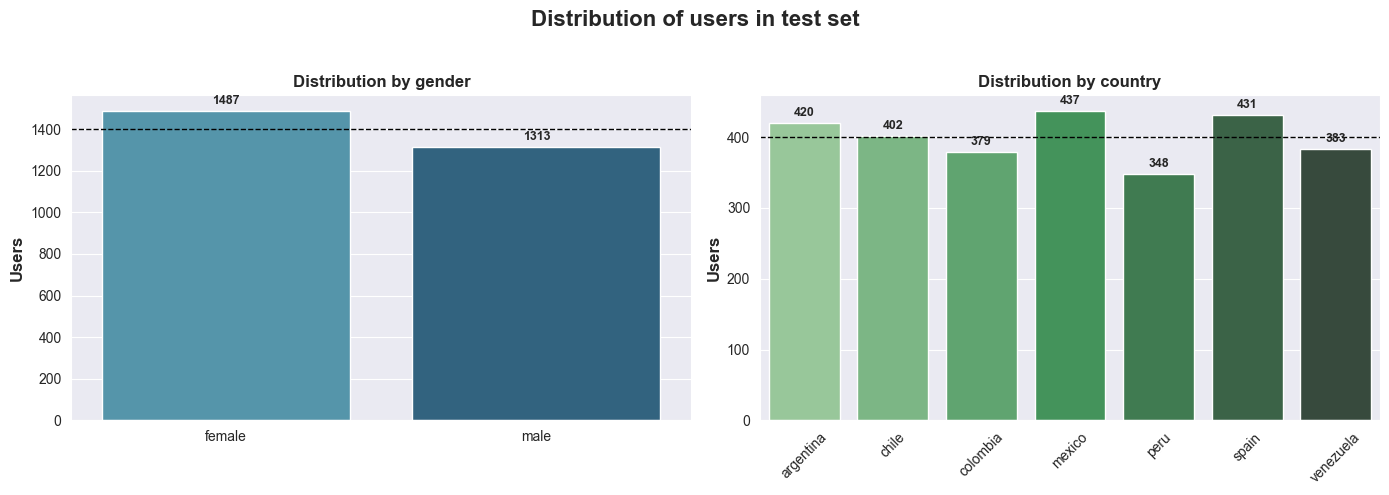

In [19]:
def plot_predictions_distribution(output_file: str) -> None:

    def annotate_bars(ax):
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height)}', xy = (bar.get_x() + bar.get_width() / 2, height), xytext = (0,3),
                            textcoords = 'offset points', ha = 'center', va = 'bottom', fontsize = 9, weight = 'bold')

    # Leer CSV ignorando cabecera si describe estructura
    df = pd.read_csv(output_file, header = None, names = ["user_id", "label"], skiprows = 1)
    df[['gender', 'country']] = df['label'].str.split(':::', expand = True)

    # Contar por género y país
    gender_counts = df["gender"].value_counts().reindex(["female", "male"])
    country_order = sorted(df["country"].unique())
    country_counts = df["country"].value_counts().reindex(country_order)

    # Crear figura
    fig, axs = plt.subplots(1, 2, figsize = (14,5))
    fig.suptitle('Distribution of users in test set', fontsize = 16, weight = 'bold')

    # Gráfico de género
    sns.barplot(x = gender_counts.index, y = gender_counts.values, hue = gender_counts.index, ax = axs[0], palette = "YlGnBu_d")
    axs[0].axhline(y = 1400, color = 'k', linestyle = '--', linewidth = 1)
    axs[0].set_title("Distribution by gender", fontsize = 12, weight = 'bold')
    axs[0].set_ylabel("Users", fontsize = 12, weight = 'bold')
    axs[0].set_xlabel("",fontsize = 12, weight = 'bold')
    annotate_bars(axs[0])

    # Gráfico de país
    sns.barplot(x = country_counts.index, y = country_counts.values, hue = country_counts.index, ax = axs[1], palette = 'Greens_d')
    axs[1].axhline(y = 400, color = 'k', linestyle = '--', linewidth = 1)
    axs[1].set_title("Distribution by country", fontsize = 12, weight = 'bold')
    axs[1].set_ylabel("Users", fontsize = 12, weight = 'bold')
    axs[1].set_xlabel("", fontsize = 12, weight = 'bold')
    axs[1].tick_params(axis = 'x', rotation = 45)
    annotate_bars(axs[1])

    plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

plot_predictions_distribution(output_file)